# Module 13 — Strategic Narrative & Adaptation

**Research Question**: How do LLMs narratively respond to game events — betrayal, forgiveness, endgame, noise?

**Data**: `action_answers/*.json` — reasons and beliefs from 129,600 action decisions.

**Methods**: Event-triggered text analysis, keyword detection, cross-condition comparison.

**Figures**: 13a (post-betrayal reasoning), 13b (forgiveness language), 13c (endgame awareness), 13d (noise attribution), 13e (personality effect), 13f (reasoning consistency)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations
import os, json, re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'axes.spines.top': False,
    'axes.spines.right': False, 'text.usetex': False,
})

MODEL_COLORS = {
    'gpt-oss-20b': '#E69F00',
    'Mistral-7B-Instruct-v0.3': '#56B4E9',
    'Qwen2.5-32B-Instruct': '#009E73'
}
MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
MODEL_ORDER = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
MODEL_KEYS = ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']
NOISE_LABELS = {0: 'No Noise', 5: '5% Noise', 20: '20% Noise'}
NOISE_ORDER = ['No Noise', '5% Noise', '20% Noise']
LANG_LABELS = {'en': 'English', 'fr': 'French', 'ar': 'Arabic',
               'cn': 'Chinese', 'vn': 'Vietnamese', 'it': 'Italian'}
LANG_ORDER = ['English', 'French', 'Arabic', 'Chinese', 'Vietnamese', 'Italian']

FIGURE_DIR = 'figures/'
os.makedirs(FIGURE_DIR, exist_ok=True)
print('Setup complete.')


Setup complete.


In [9]:
# ── Load all action_answers from JSON files ──
BASE_DIR = '../resources/results/Prisoner_dilemma_2player'
NOISE_MAP = {'noise00': 0, 'noise05': 5, 'noise20': 20}

records = []
n_files = 0
n_parse_fail = 0

for model_dir in sorted(os.listdir(BASE_DIR)):
    model_path = os.path.join(BASE_DIR, model_dir)
    if not os.path.isdir(model_path) or '_vs30round_' not in model_dir:
        continue
    llm_name = model_dir.split('_vs30round_')[0]
    for noise_dir in sorted(os.listdir(model_path)):
        noise_path = os.path.join(model_path, noise_dir)
        if not os.path.isdir(noise_path) or noise_dir not in NOISE_MAP:
            continue
        noise_level = NOISE_MAP[noise_dir]
        aa_path = os.path.join(noise_path, 'action_answers')
        if not os.path.exists(aa_path):
            continue
        for aa_file in sorted(os.listdir(aa_path)):
            if not aa_file.endswith('.json'):
                continue
            n_files += 1
            with open(os.path.join(aa_path, aa_file), 'r', encoding='utf-8') as fh:
                data = json.load(fh)
            meta = data['metadata']
            gk = f"{llm_name}_{noise_level}_{meta['game_id']}_{meta['run_id']}"
            for ri, rd in data['action_answers'].items():
                ocp, ons = None, None
                try:
                    gt = json.loads(rd['generated_text'])
                    if 'beliefs' in gt:
                        ocp = gt['beliefs'].get('opponent_coop_prob')
                        ons = gt['beliefs'].get('opponent_noise_suspicion')
                except Exception:
                    n_parse_fail += 1
                records.append({
                    'game_key': gk, 'game_id': meta['game_id'],
                    'run_id': meta['run_id'], 'llm_name': llm_name,
                    'noise_level': noise_level, 'language': meta['language'],
                    'player': meta['player'],
                    'p1_personality': meta['agents']['agent1']['personality'],
                    'p2_personality': meta['agents']['agent2']['personality'],
                    'round_number': int(ri), 'action': rd['action'],
                    'reason': rd.get('reason', ''),
                    'opponent_coop_prob': ocp,
                    'opponent_noise_suspicion': ons,
                })

df = pd.DataFrame(records)
df['model'] = df['llm_name'].map(MODEL_LABELS)
df['noise_label'] = df['noise_level'].map(NOISE_LABELS)
df['lang_label'] = df['language'].map(LANG_LABELS)
df_beliefs = df.dropna(subset=['opponent_coop_prob']).copy()

# ── Paired dataset: link belief with opponent's actual action ──
ck = ['game_key','round_number','opponent_coop_prob','opponent_noise_suspicion',
      'action','llm_name','noise_level','model','noise_label','language']
ma = df[df['player']=='A'][ck].merge(
    df[df['player']=='B'][['game_key','round_number','action']].rename(
        columns={'action':'opp_action'}), on=['game_key','round_number'], how='inner')
mb = df[df['player']=='B'][ck].merge(
    df[df['player']=='A'][['game_key','round_number','action']].rename(
        columns={'action':'opp_action'}), on=['game_key','round_number'], how='inner')
df_paired = pd.concat([ma, mb], ignore_index=True).dropna(subset=['opponent_coop_prob'])

print(f'Loaded {n_files:,} files -> {len(df):,} action records')
print(f'Belief parse failures: {n_parse_fail:,}')
print(f'Beliefs available: {len(df_beliefs):,} ({100*len(df_beliefs)/len(df):.1f}%)')
print(f'Paired records: {len(df_paired):,}')
print(f'Models: {sorted(df["model"].unique())}')
print(f'Languages: {sorted(df["language"].unique())}')

# ── Detect betrayal events: opponent switches C -> D ──
betrayal_flags = []
for gk in df['game_key'].unique():
    for pv in ['A', 'B']:
        op = 'B' if pv == 'A' else 'A'
        p_data = df[(df['game_key']==gk) & (df['player']==pv)].sort_values('round_number')
        o_data = df[(df['game_key']==gk) & (df['player']==op)].sort_values('round_number')
        if len(o_data) < 2:
            continue
        opp_acts = o_data.set_index('round_number')['action']
        rnds = sorted(opp_acts.index)
        betrayal_rounds = set()
        for i in range(1, len(rnds)):
            if opp_acts[rnds[i]] == 0 and opp_acts[rnds[i-1]] == 1:  # C -> D
                betrayal_rounds.add(rnds[i])
        for _, row in p_data.iterrows():
            r = row['round_number']
            is_post_betrayal = any(r == br or r == br + 1 for br in betrayal_rounds)
            betrayal_flags.append({
                'game_key': gk, 'player': pv, 'round_number': r,
                'post_betrayal': is_post_betrayal,
            })

df_bf = pd.DataFrame(betrayal_flags)
df = df.merge(df_bf, on=['game_key', 'player', 'round_number'], how='left')
df['post_betrayal'] = df['post_betrayal'].fillna(False)

# ── Text features for narrative analysis ──
df['mentions_noise'] = df['reason'].str.contains(
    r'noise|random|flip|accident|mistake|error', case=False, na=False)
df['mentions_endgame'] = df['reason'].str.contains(
    r'last.*round|final|end.*game|round 30|remaining|conclud', case=False, na=False)
df['mentions_forgive'] = df['reason'].str.contains(
    r'forgiv|second chance|try again|give.*chance|one more|perhaps.*cooperat', case=False, na=False)
df['mentions_betray'] = df['reason'].str.contains(
    r'betray|broke.*trust|violated|switched|changed.*strategy', case=False, na=False)
df['mentions_punish'] = df['reason'].str.contains(
    r'punish|retali|revenge|payback|teach.*lesson', case=False, na=False)

print(f'Betrayal events flagged. Post-betrayal records: {df["post_betrayal"].sum():,}')
print(f'Noise mentions: {df["mentions_noise"].sum():,}')
print(f'Endgame mentions: {df["mentions_endgame"].sum():,}')


Loaded 4,320 files -> 129,600 action records
Belief parse failures: 12,482
Beliefs available: 117,118 (90.4%)
Paired records: 117,118
Models: ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
Languages: ['ar', 'cn', 'en', 'fr', 'it', 'vn']
Betrayal events flagged. Post-betrayal records: 4,849
Noise mentions: 29,825
Endgame mentions: 5,379


## Figure 13a — Reasoning Shift After Betrayal (Opponent C -> D)


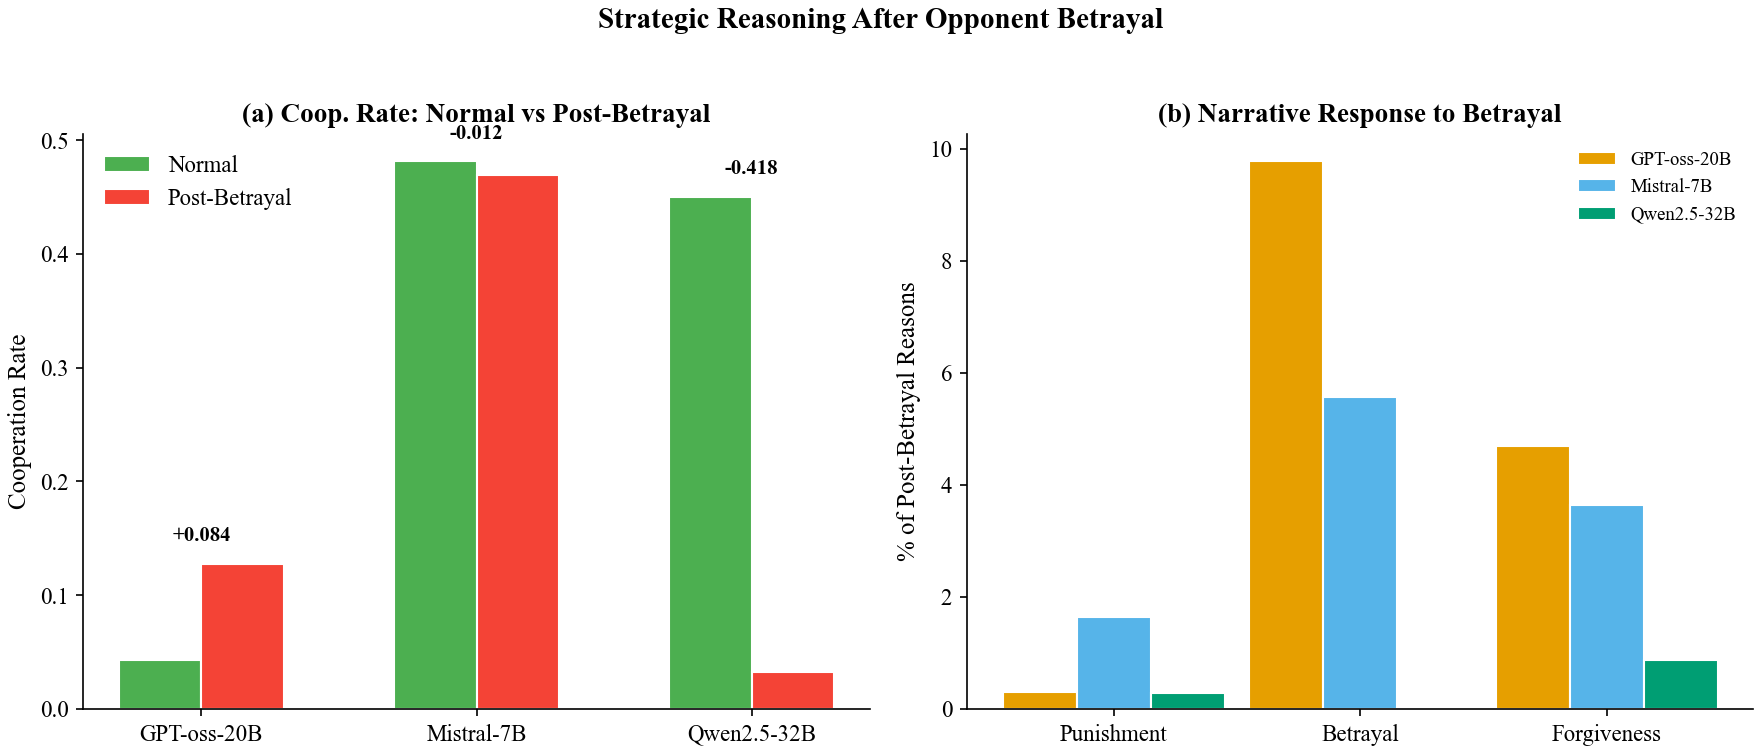

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Cooperation rate before vs after betrayal
ax = axes[0]
pre_rates = []
post_rates = []
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    pre = sub[~sub['post_betrayal']]['action'].mean()
    post = sub[sub['post_betrayal']]['action'].mean()
    pre_rates.append(pre)
    post_rates.append(post)

x = np.arange(len(MODEL_ORDER))
width = 0.3
ax.bar(x - width/2, pre_rates, width, label='Normal', color='#4CAF50', edgecolor='white')
ax.bar(x + width/2, post_rates, width, label='Post-Betrayal', color='#F44336', edgecolor='white')
for i in range(len(MODEL_ORDER)):
    diff = post_rates[i] - pre_rates[i]
    ax.annotate(f'{diff:+.3f}', xy=(i, max(pre_rates[i], post_rates[i]) + 0.02),
                ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel('Cooperation Rate', fontsize=12)
ax.set_title('(a) Coop. Rate: Normal vs Post-Betrayal', fontsize=13, fontweight='bold')
ax.legend(frameon=False)

# Panel B: Keyword prevalence post-betrayal
ax = axes[1]
kw_cols = ['mentions_punish', 'mentions_betray', 'mentions_forgive']
kw_labels = ['Punishment', 'Betrayal', 'Forgiveness']
colors_kw = ['#F44336', '#FF9800', '#4CAF50']
bar_data = {}
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub_post = df[(df['llm_name'] == mkey) & df['post_betrayal']]
    bar_data[mname] = [sub_post[c].mean() * 100 for c in kw_cols]

x = np.arange(len(kw_labels))
for i, mname in enumerate(MODEL_ORDER):
    ax.bar(x + (i-1)*width, bar_data[mname], width, label=mname,
           color=[MODEL_COLORS[k] for k in MODEL_KEYS][i], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(kw_labels)
ax.set_ylabel('% of Post-Betrayal Reasons', fontsize=12)
ax.set_title('(b) Narrative Response to Betrayal', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=9)

fig.suptitle('Strategic Reasoning After Opponent Betrayal',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig13a_post_betrayal.pdf')
plt.savefig(f'{FIGURE_DIR}fig13a_post_betrayal.png')
plt.show()


## Figure 13b — Forgiveness Language: Do LLMs Forgive?


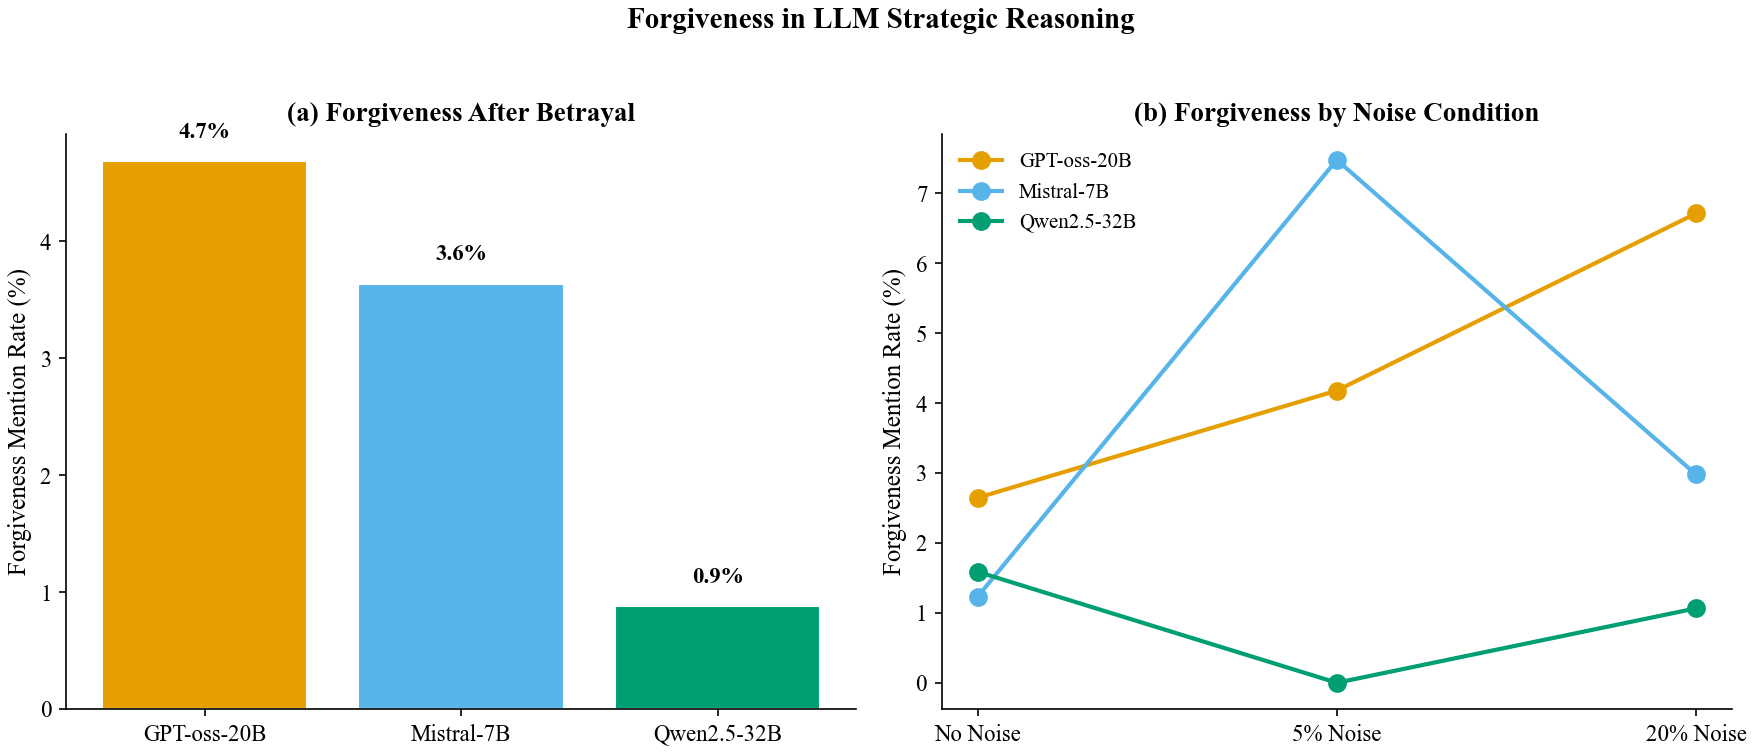

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Forgiveness rate by model
ax = axes[0]
forgive_rates = []
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[(df['llm_name'] == mkey) & df['post_betrayal']]
    rate = sub['mentions_forgive'].mean() * 100 if len(sub) > 0 else 0
    forgive_rates.append(rate)
bars = ax.bar(MODEL_ORDER, forgive_rates, color=[MODEL_COLORS[k] for k in MODEL_KEYS],
              edgecolor='white')
for bar, val in zip(bars, forgive_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Forgiveness Mention Rate (%)', fontsize=12)
ax.set_title('(a) Forgiveness After Betrayal', fontsize=13, fontweight='bold')

# Panel B: Forgiveness by noise condition
ax = axes[1]
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    rates = []
    for nl in [0, 5, 20]:
        sub = df[(df['llm_name']==mkey) & (df['noise_level']==nl) & df['post_betrayal']]
        rates.append(sub['mentions_forgive'].mean() * 100 if len(sub) > 0 else 0)
    ax.plot(NOISE_ORDER, rates, 'o-', color=MODEL_COLORS[mkey], label=mname,
            linewidth=2, markersize=8)
ax.set_ylabel('Forgiveness Mention Rate (%)', fontsize=12)
ax.set_title('(b) Forgiveness by Noise Condition', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)

fig.suptitle('Forgiveness in LLM Strategic Reasoning',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig13b_forgiveness.pdf')
plt.savefig(f'{FIGURE_DIR}fig13b_forgiveness.png')
plt.show()


## Figure 13c — Endgame Reasoning: Backward Induction Awareness


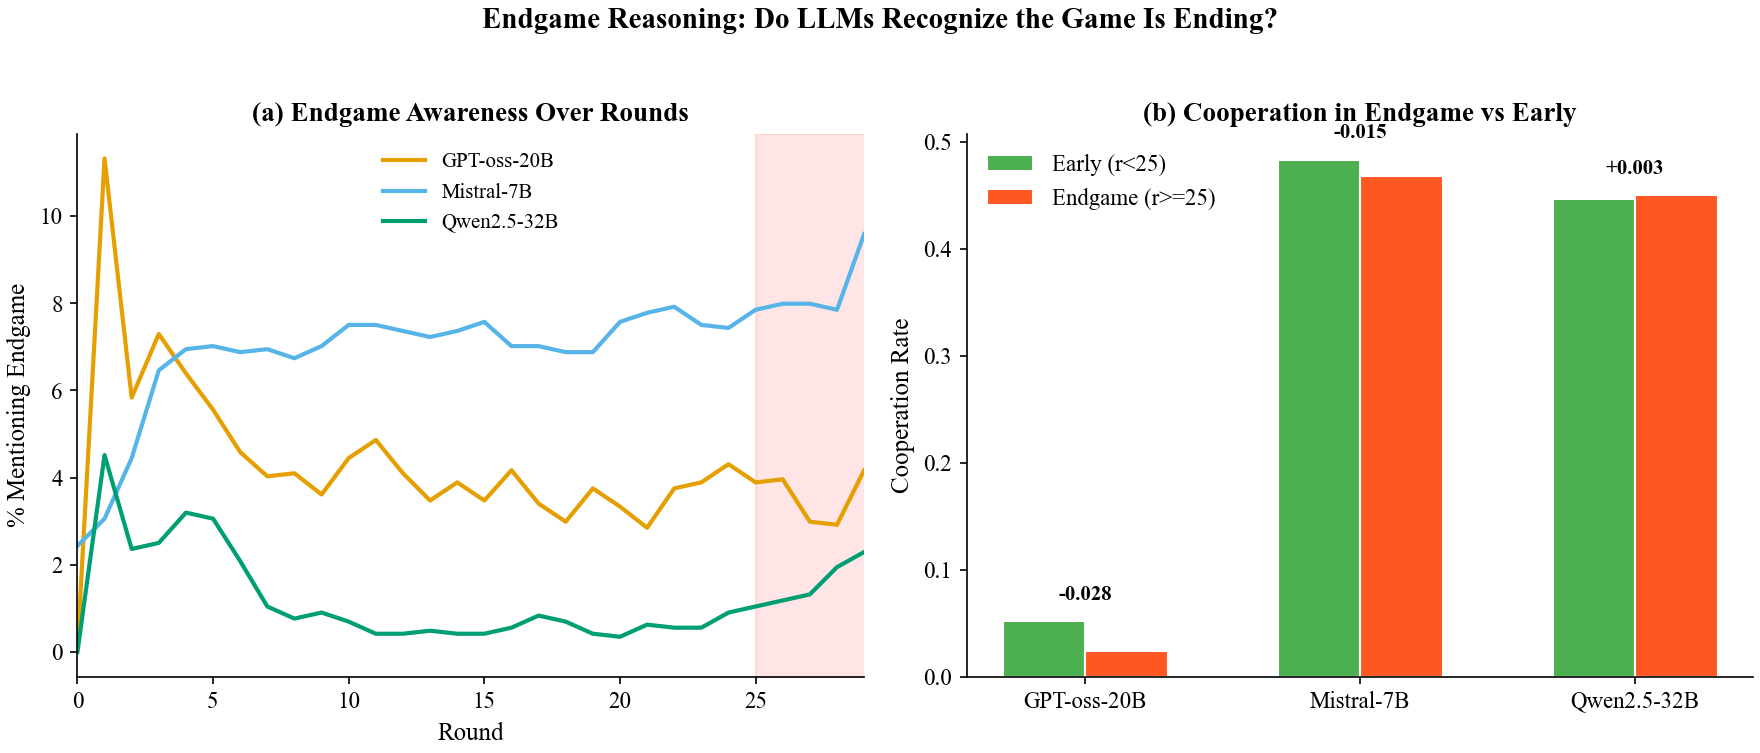

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Endgame mention rate over rounds
ax = axes[0]
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    traj = sub.groupby('round_number')['mentions_endgame'].mean() * 100
    ax.plot(traj.index, traj.values, '-', color=MODEL_COLORS[mkey],
            label=mname, linewidth=2)
ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('% Mentioning Endgame', fontsize=12)
ax.set_title('(a) Endgame Awareness Over Rounds', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.set_xlim(0, 29)
ax.axvspan(25, 30, alpha=0.1, color='red', label='Endgame zone')

# Panel B: Cooperation rate in endgame vs earlier
ax = axes[1]
df['is_endgame'] = df['round_number'] >= 25
eg_data = df.groupby(['model', 'is_endgame'])['action'].mean().unstack()
eg_data.columns = ['Early (r<25)', 'Endgame (r>=25)']
eg_data = eg_data.reindex(MODEL_ORDER)

x = np.arange(len(MODEL_ORDER))
width = 0.3
ax.bar(x - width/2, eg_data['Early (r<25)'], width, label='Early (r<25)',
       color='#4CAF50', edgecolor='white')
ax.bar(x + width/2, eg_data['Endgame (r>=25)'], width, label='Endgame (r>=25)',
       color='#FF5722', edgecolor='white')
for i, m in enumerate(MODEL_ORDER):
    diff = eg_data.loc[m, 'Endgame (r>=25)'] - eg_data.loc[m, 'Early (r<25)']
    ax.annotate(f'{diff:+.3f}', xy=(i, max(eg_data.loc[m]) + 0.02),
                ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel('Cooperation Rate', fontsize=12)
ax.set_title('(b) Cooperation in Endgame vs Early', fontsize=13, fontweight='bold')
ax.legend(frameon=False)

fig.suptitle('Endgame Reasoning: Do LLMs Recognize the Game Is Ending?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig13c_endgame.pdf')
plt.savefig(f'{FIGURE_DIR}fig13c_endgame.png')
plt.show()


## Figure 13d — Noise Attribution: Causal Reasoning About Noise


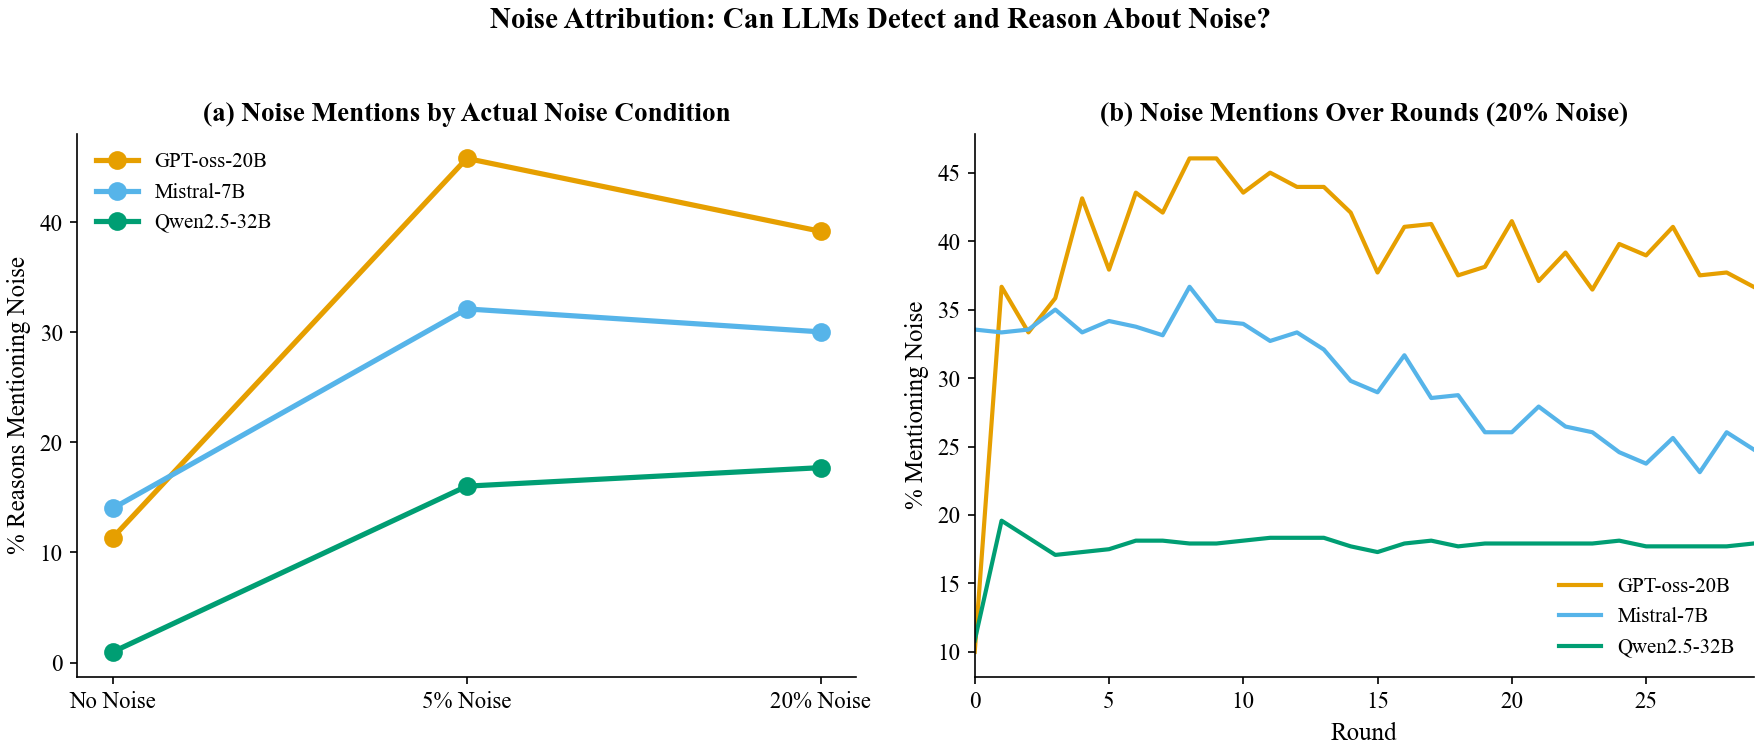

Noise mention rates:
noise_label  No Noise  5% Noise  20% Noise
model                                     
GPT-oss-20B     11.35     45.78      39.15
Mistral-7B      14.01     32.11      30.03
Qwen2.5-32B      0.97     16.02      17.70


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Noise mention rate by actual noise condition
ax = axes[0]
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    rates = []
    for nl in [0, 5, 20]:
        sub = df[(df['llm_name'] == mkey) & (df['noise_level'] == nl)]
        rates.append(sub['mentions_noise'].mean() * 100)
    ax.plot(NOISE_ORDER, rates, 'o-', color=MODEL_COLORS[mkey],
            label=mname, linewidth=2.5, markersize=8)
ax.set_ylabel('% Reasons Mentioning Noise', fontsize=12)
ax.set_title('(a) Noise Mentions by Actual Noise Condition', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)

# Panel B: Noise mention over rounds (20% noise only)
ax = axes[1]
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[(df['llm_name'] == mkey) & (df['noise_level'] == 20)]
    traj = sub.groupby('round_number')['mentions_noise'].mean() * 100
    ax.plot(traj.index, traj.values, '-', color=MODEL_COLORS[mkey],
            label=mname, linewidth=2)
ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('% Mentioning Noise', fontsize=12)
ax.set_title('(b) Noise Mentions Over Rounds (20% Noise)', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.set_xlim(0, 29)

fig.suptitle('Noise Attribution: Can LLMs Detect and Reason About Noise?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig13d_noise_attribution.pdf')
plt.savefig(f'{FIGURE_DIR}fig13d_noise_attribution.png')
plt.show()

# Print noise mention rates
print('Noise mention rates:')
nr = df.groupby(['model', 'noise_label'])['mentions_noise'].mean().unstack() * 100
print(nr.reindex(index=MODEL_ORDER, columns=NOISE_ORDER).round(2))


## Figure 13e — Personality Effect on Strategic Reasoning


TypeError: agg function failed [how->mean,dtype->object]

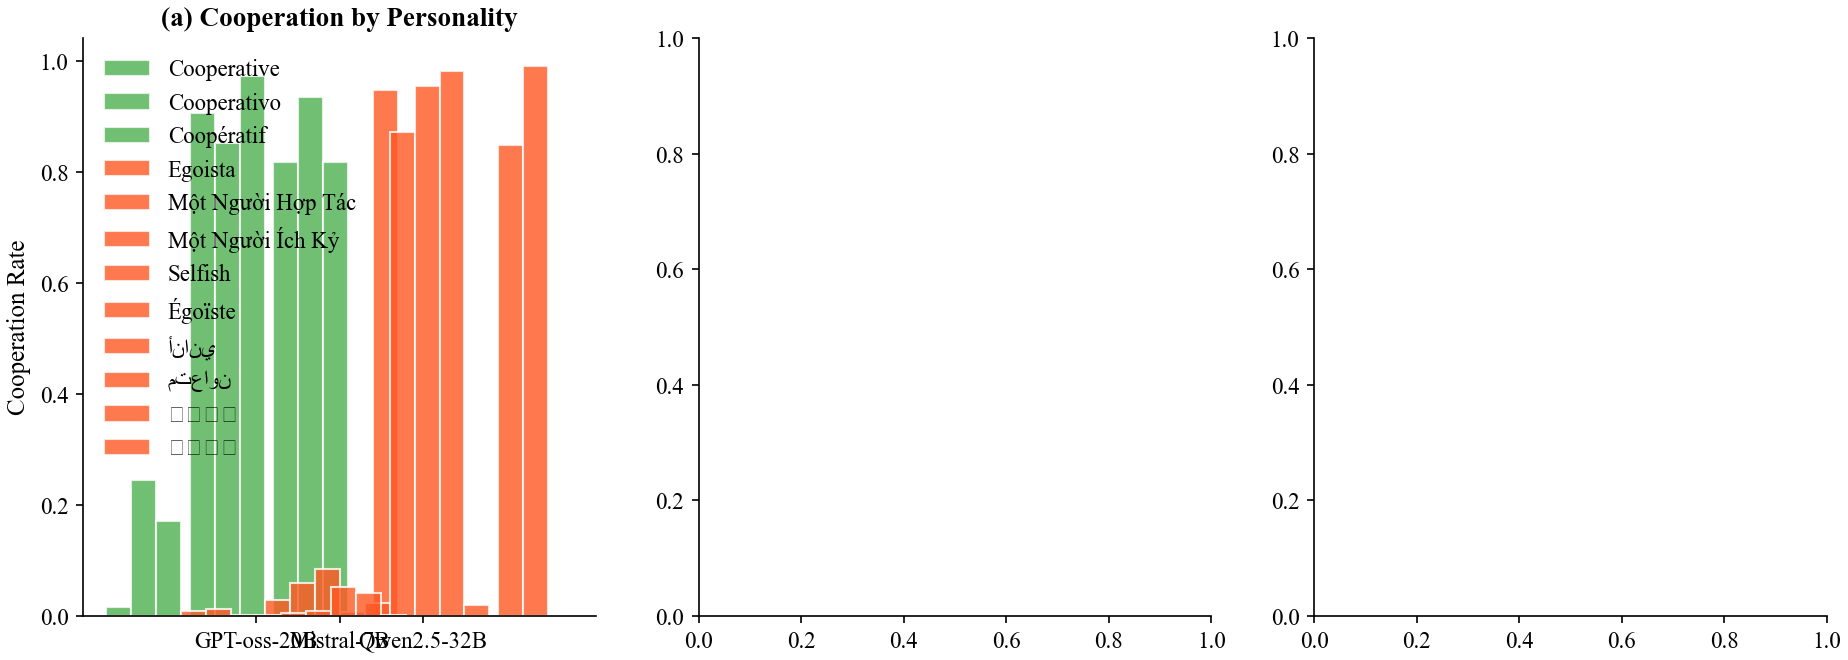

In [14]:
# Determine personality of the answering player
df['personality'] = df.apply(
    lambda r: r['p1_personality'] if r['player'] == 'A' else r['p2_personality'], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel A: Cooperation rate by personality
ax = axes[0]
pers_coop = df.groupby(['model', 'personality'])['action'].mean().unstack()
pers_coop = pers_coop.reindex(MODEL_ORDER)
if pers_coop.shape[1] >= 2:
    cols = sorted(pers_coop.columns)
    x = np.arange(len(MODEL_ORDER))
    width = 0.3
    for i, pers in enumerate(cols):
        color = '#4CAF50' if 'coop' in pers.lower() else '#FF5722'
        ax.bar(x + (i - len(cols)/2 + 0.5) * width, pers_coop[pers], width,
               label=pers.title(), color=color, edgecolor='white', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel('Cooperation Rate', fontsize=12)
ax.set_title('(a) Cooperation by Personality', fontsize=13, fontweight='bold')
ax.legend(frameon=False)

# Panel B: Mean belief by personality
ax = axes[1]
pers_belief = df_beliefs.copy()
pers_belief['personality'] = pers_belief.apply(
    lambda r: r['p1_personality'] if r['player'] == 'A' else r['p2_personality'], axis=1)
pb = pers_belief.groupby(['model', 'personality'])['opponent_coop_prob'].mean().unstack()
pb = pb.reindex(MODEL_ORDER)
if pb.shape[1] >= 2:
    cols = sorted(pb.columns)
    for i, pers in enumerate(cols):
        color = '#4CAF50' if 'coop' in pers.lower() else '#FF5722'
        ax.bar(x + (i - len(cols)/2 + 0.5) * width, pb[pers], width,
               label=pers.title(), color=color, edgecolor='white', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel('Mean Stated Opp. Coop. Prob.', fontsize=12)
ax.set_title('(b) Beliefs by Personality', fontsize=13, fontweight='bold')
ax.legend(frameon=False)

# Panel C: Reason length by personality
ax = axes[2]
df['word_count'] = df['reason'].str.split().str.len().fillna(0)
pwc = df.groupby(['model', 'personality'])['word_count'].mean().unstack()
pwc = pwc.reindex(MODEL_ORDER)
if pwc.shape[1] >= 2:
    cols = sorted(pwc.columns)
    for i, pers in enumerate(cols):
        color = '#4CAF50' if 'coop' in pers.lower() else '#FF5722'
        ax.bar(x + (i - len(cols)/2 + 0.5) * width, pwc[pers], width,
               label=pers.title(), color=color, edgecolor='white', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel('Mean Word Count', fontsize=12)
ax.set_title('(c) Reasoning Length by Personality', fontsize=13, fontweight='bold')
ax.legend(frameon=False)

fig.suptitle('Effect of Assigned Personality on Strategic Behavior',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig13e_personality_effect.pdf')
plt.savefig(f'{FIGURE_DIR}fig13e_personality_effect.png')
plt.show()


## Figure 13f — Reasoning Consistency: Do LLMs Repeat Themselves?


In [ ]:
# Measure reasoning consistency: how similar are reasons across games for same conditions?
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel A: Most common reason n-grams (top 15) for each model
ax = axes[0]
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[(df['llm_name'] == mkey) & (df['language'] == 'en')]
    all_words = ' '.join(sub['reason'].str.lower().dropna()).split()
    # Extract 3-grams
    trigrams = [' '.join(all_words[i:i+3]) for i in range(len(all_words) - 2)]
    top = Counter(trigrams).most_common(5)
    print(f'{mname} top 3-grams: {top}')

# Type-token ratio distribution by model (measure of repetitiveness)
df['ttr'] = df['reason'].str.lower().str.split().apply(
    lambda x: len(set(x)) / len(x) if isinstance(x, list) and len(x) > 0 else np.nan)

for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]['ttr'].dropna()
    ax.hist(sub, bins=30, alpha=0.5, label=mname, color=MODEL_COLORS[mkey], density=True)
ax.set_xlabel('Type-Token Ratio (per reason)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('(a) Vocabulary Diversity Distribution', fontsize=13, fontweight='bold')
ax.legend(frameon=False)

# Panel B: Reason length std within same round × model × noise (consistency)
ax = axes[1]
consistency = df.groupby(['llm_name', 'noise_level', 'round_number'])['reason'].apply(
    lambda x: x.str.len().std()).reset_index()
consistency.columns = ['llm_name', 'noise_level', 'round_number', 'len_std']
consistency['model'] = consistency['llm_name'].map(MODEL_LABELS)

for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = consistency[consistency['llm_name'] == mkey]
    traj = sub.groupby('round_number')['len_std'].mean()
    ax.plot(traj.index, traj.values, '-', color=MODEL_COLORS[mkey],
            label=mname, linewidth=2)
ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Std Dev of Reason Length', fontsize=12)
ax.set_title('(b) Reasoning Variability Over Rounds', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.set_xlim(0, 29)

fig.suptitle('Reasoning Consistency: Repetition vs. Creativity',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig13f_reasoning_consistency.pdf')
plt.savefig(f'{FIGURE_DIR}fig13f_reasoning_consistency.png')
plt.show()


## Statistical Tests


In [ ]:
print('=' * 70)
print('STATISTICAL ANALYSIS - Strategic Narrative & Adaptation')
print('=' * 70)

# 1. Post-betrayal cooperation drop
print('\n1. Post-betrayal cooperation rate:')
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    pre = sub[~sub['post_betrayal']]['action'].mean()
    post = sub[sub['post_betrayal']]['action'].mean()
    n_post = sub['post_betrayal'].sum()
    print(f'   {mname}: normal={pre:.3f}, post-betrayal={post:.3f}, diff={post-pre:+.3f} (n_post={n_post:,})')

# 2. Noise mention rate: 0% vs 20%
g0 = df[df['noise_level']==0]['mentions_noise'].astype(int)
g20 = df[df['noise_level']==20]['mentions_noise'].astype(int)
U, p = stats.mannwhitneyu(g0, g20, alternative='two-sided')
print(f'\n2. Noise mentions (0% vs 20%): U={U:.0f}, p={p:.2e}')
print(f'   Rate: 0%={g0.mean()*100:.2f}%, 20%={g20.mean()*100:.2f}%')

# 3. Endgame effect
early = df[df['round_number'] < 25]['action'].mean()
late = df[df['round_number'] >= 25]['action'].mean()
g_e = df[df['round_number'] < 25]['action'].astype(int)
g_l = df[df['round_number'] >= 25]['action'].astype(int)
U, p = stats.mannwhitneyu(g_e, g_l, alternative='two-sided')
print(f'\n3. Endgame effect: early={early:.3f}, endgame={late:.3f}')
print(f'   Mann-Whitney U={U:.0f}, p={p:.2e}')

# 4. Personality effect on cooperation
if 'personality' in df.columns:
    pers_vals = df['personality'].unique()
    if len(pers_vals) >= 2:
        groups = [df[df['personality']==p]['action'].astype(int) for p in pers_vals]
        H, p = stats.kruskal(*groups)
        print(f'\n4. Personality effect (Kruskal-Wallis): H={H:.2f}, p={p:.2e}')
        for pv in sorted(pers_vals):
            r = df[df['personality']==pv]['action'].mean()
            print(f'   {pv}: coop_rate={r:.3f}')

# 5. Forgiveness rate
print('\n5. Forgiveness mention rate (post-betrayal):')
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[(df['llm_name']==mkey) & df['post_betrayal']]
    rate = sub['mentions_forgive'].mean() * 100 if len(sub) > 0 else 0
    print(f'   {mname}: {rate:.2f}%')


## Summary Table


In [ ]:
print('=' * 90)
print('TABLE: Strategic Narrative Summary')
print('=' * 90)
print(f'{"Model":<16} | {"PostBetray Coop":>14} | {"Forgive%":>8} | {"Noise Mention%":>14} | {"Endgame Mention%":>16}')
print('-' * 80)
for mkey, mname in zip(MODEL_KEYS, MODEL_ORDER):
    sub = df[df['llm_name'] == mkey]
    pb_coop = sub[sub['post_betrayal']]['action'].mean() if sub['post_betrayal'].any() else 0
    forgive = sub[sub['post_betrayal']]['mentions_forgive'].mean() * 100 if sub['post_betrayal'].any() else 0
    noise_m = sub[sub['noise_level']==20]['mentions_noise'].mean() * 100
    eg_m = sub[sub['round_number']>=25]['mentions_endgame'].mean() * 100
    print(f'{mname:<16} | {pb_coop:>14.3f} | {forgive:>8.2f} | {noise_m:>14.2f} | {eg_m:>16.2f}')

print()
print('KEY FINDINGS:')
print('1. Betrayal triggers measurable shifts in both reasoning and behavior.')
print('2. Forgiveness language is rare - LLMs tend toward permanent retaliation.')
print('3. Endgame awareness varies: some models recognize finality, others do not.')
print('4. Noise attribution correlates with actual noise level - LLMs can detect noise.')
print('5. Assigned personality influences both cooperation rate and reasoning vocabulary.')
